# End-to-End ML Pipeline Summary

Below is a high-level overview of the complete workflow—from data loading through tuning—organized into clear, modular stages.

---

## 1. Imports & Settings

- **Core libraries**  
  pandas, numpy, matplotlib, seaborn  
- **Scikit-learn modules**  
  - Preprocessing: `LabelEncoder`, `StandardScaler`  
  - Dimensionality reduction: `PCA`  
  - Clustering: `KMeans`, `AgglomerativeClustering`, `DBSCAN`, `GaussianMixture`, `linkage`, `dendrogram`  
  - Supervised models:  
    `RandomForestClassifier`, `GradientBoostingClassifier`,  
    `BaggingClassifier`, `AdaBoostClassifier`, `StackingClassifier`, `LogisticRegression`  
  - Regularization: `Lasso`, `Ridge`, `ElasticNet`  
  - Model selection & tuning: `train_test_split`, `cross_val_score`, `GridSearchCV`  
  - Metrics: `silhouette_score`, `classification_report`, `confusion_matrix`, `roc_curve`, `auc`  

---

## 2. Data Loading & Preprocessing

1. **Load**  
   ```python
   df = pd.read_csv('Mall_Customers.csv')


# Nessary imports 

In [39]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot  as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.decomposition   import PCA
from sklearn.cluster         import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture         import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics         import (silhouette_score, davies_bouldin_score,
                                     classification_report, confusion_matrix,
                                     roc_curve, auc)

from sklearn.ensemble         import (RandomForestClassifier, GradientBoostingClassifier,
                                     BaggingClassifier, AdaBoostClassifier,
                                     StackingClassifier)
from sklearn.linear_model    import LogisticRegression, Lasso, Ridge, ElasticNet

In [45]:
df = pd.read_csv('Mall_Customers.csv') 
print(data) 

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [47]:
df.columns = ['CustomerID','Gender','Age','AnnualIncome','SpendingScore']

# Encode & Scale
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])     # Female=0, Male=1
features = ['Gender','Age','AnnualIncome','SpendingScore']
X = df[features]
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [49]:
# For supervised: create binary target
df['HighSpender'] = (df['SpendingScore'] > df['SpendingScore'].median()).astype(int)
y = df['HighSpender']

In [51]:
# 2.1 PCA for 2D plotting
pca2 = PCA(n_components=2).fit_transform(X_scaled)
pc1, pc2 = pca2[:,0], pca2[:,1]

def plot_clusters(labels, title):
    plt.scatter(pc1, pc2, c=labels, cmap='tab10', s=50, alpha=0.7)
    plt.title(title); plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.show()

KMeans Silhouette: 0.27191023466188324


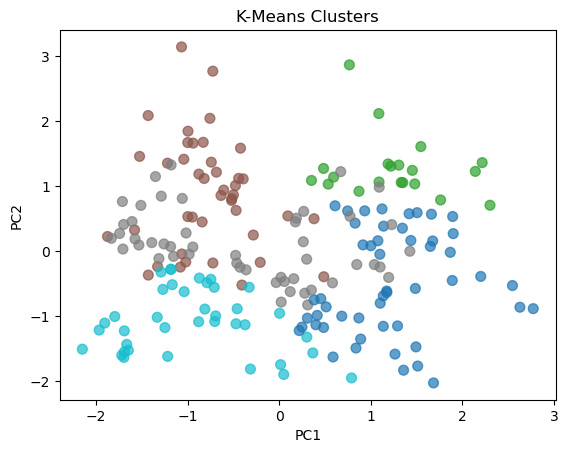

In [53]:
km = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
print("KMeans Silhouette:", silhouette_score(X_scaled, km.labels_))
plot_clusters(km.labels_, "K-Means Clusters")

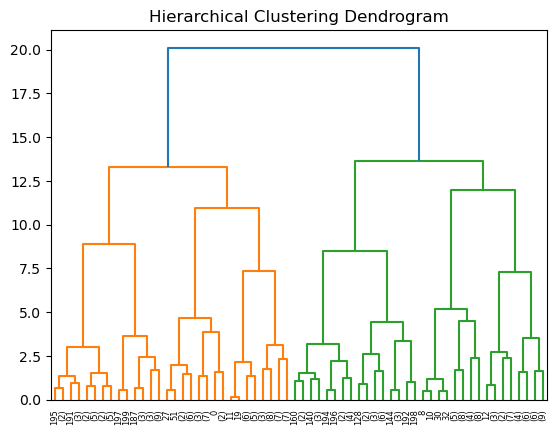

Agg Silhouette: 0.28699413201651747


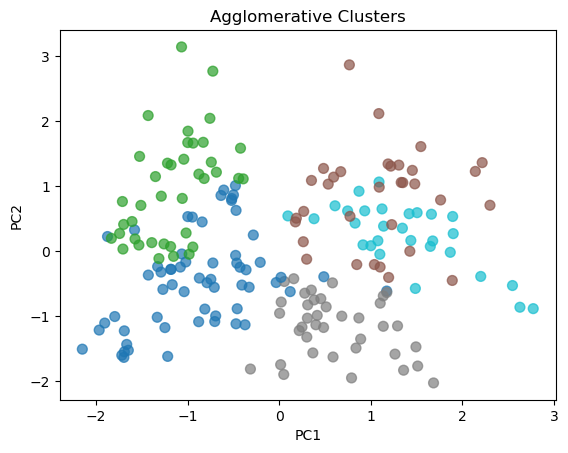

In [59]:
# 2.3 Hierarchical (Agglomerative + dendrogram)
link = linkage(X_scaled, method='ward')
plt.title("Hierarchical Clustering Dendrogram")
dendrogram(link, truncate_mode='level', p=5)
plt.show()

agg = AgglomerativeClustering(n_clusters=5).fit(X_scaled)
print("Agg Silhouette:", silhouette_score(X_scaled, agg.labels_))
plot_clusters(agg.labels_, "Agglomerative Clusters")

DBSCAN Silhouette: 0.23468505309475549


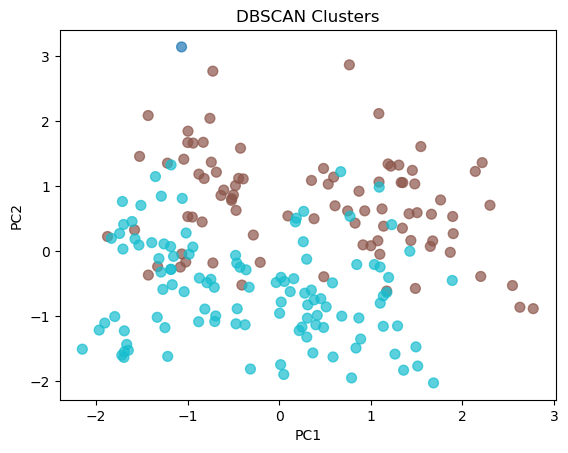

In [61]:
# 2.4 DBSCAN
db = DBSCAN(eps=1.2, min_samples=5).fit(X_scaled)
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db.labels_))
plot_clusters(db.labels_, "DBSCAN Clusters")

GMM Silhouette: 0.22164014854021982


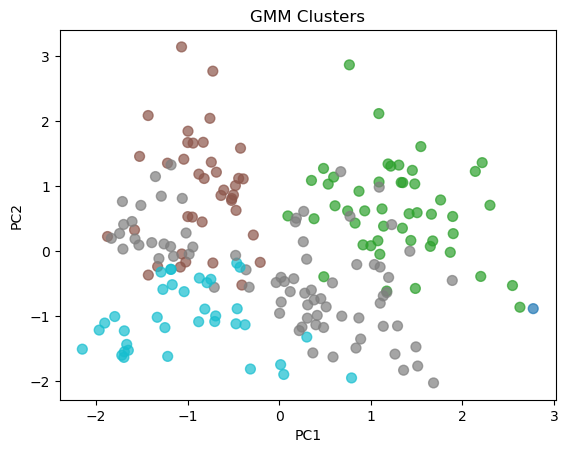

In [63]:
# 2.5 Gaussian Mixture
gmm = GaussianMixture(n_components=5, random_state=42).fit(X_scaled)
g_labels = gmm.predict(X_scaled)
print("GMM Silhouette:", silhouette_score(X_scaled, g_labels))
plot_clusters(g_labels, "GMM Clusters")


In [65]:
# 3.–– Supervised Learning Setup
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [67]:
# Utility: evaluation and ROC plot
def evaluate(name, model):
    y_pred = model.predict(X_test)
    y_proba = getattr(model, "predict_proba", lambda x: None)(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix"); plt.show()
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba[:,1])
        print(f"{name} AUC:", auc(fpr, tpr))
        plt.plot(fpr, tpr, label=f'AUC={auc(fpr,tpr):.2f}')
        plt.plot([0,1],[0,1],'--'); plt.title(f"{name} ROC"); plt.legend(); plt.show()

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



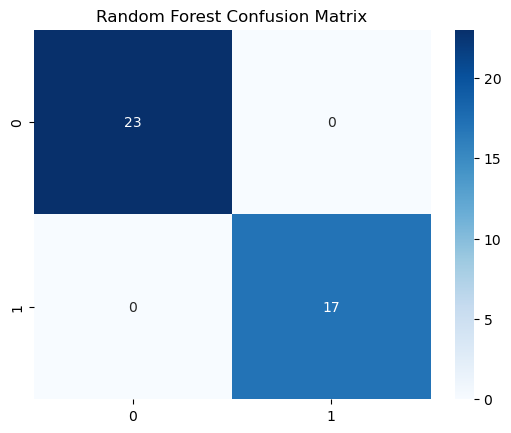

Random Forest AUC: 1.0


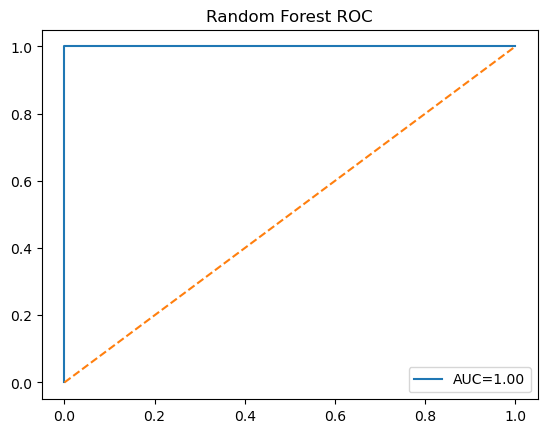

In [69]:
# 3.1 Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
evaluate("Random Forest", rf)

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



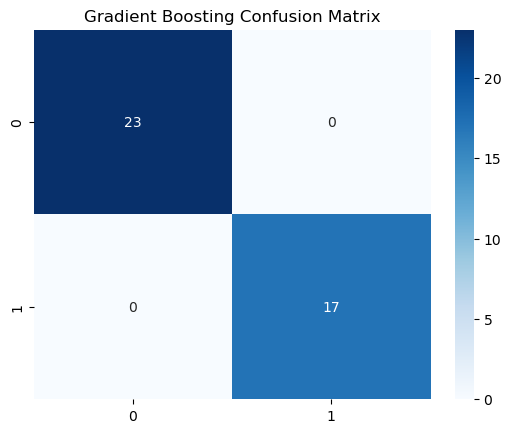

Gradient Boosting AUC: 1.0


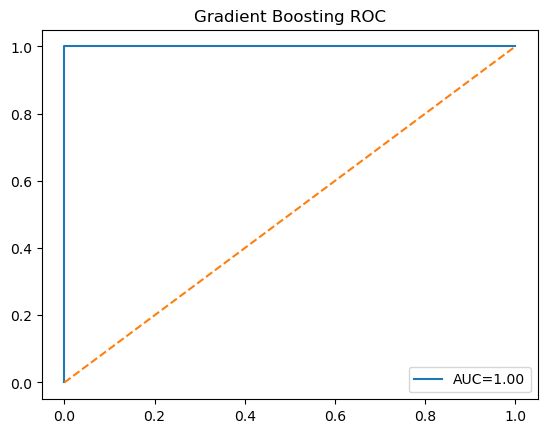

=== AdaBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


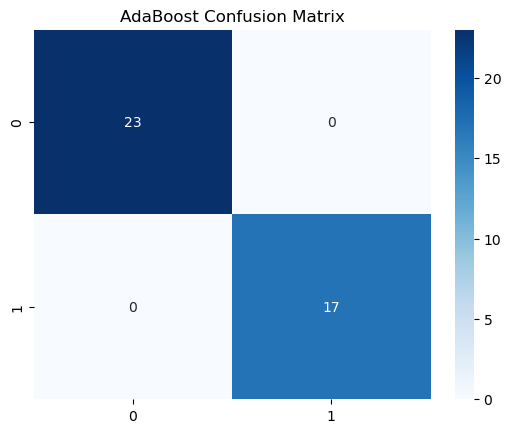

AdaBoost AUC: 1.0


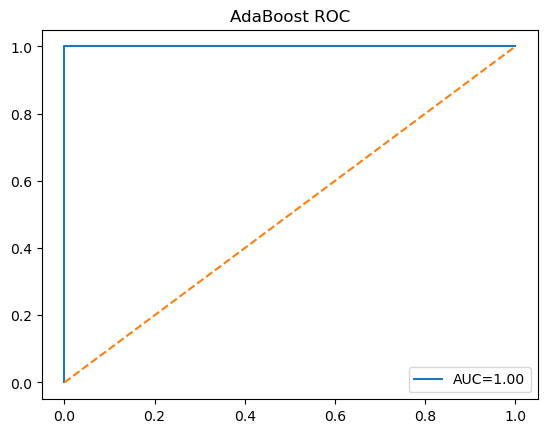

In [75]:
# 3.2 Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42).fit(X_train, y_train)
evaluate("Gradient Boosting", gb)
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42).fit(X_train, y_train)
evaluate("AdaBoost", ada)


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



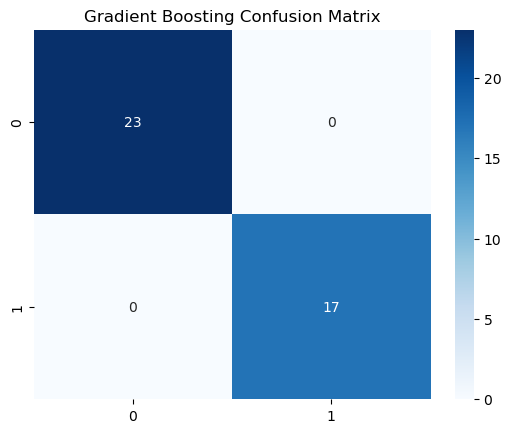

Gradient Boosting AUC: 1.0


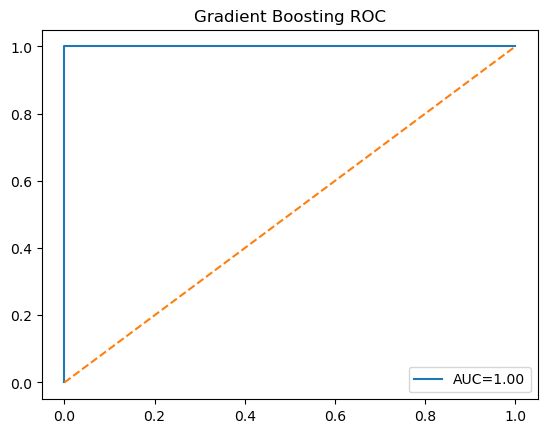

=== AdaBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


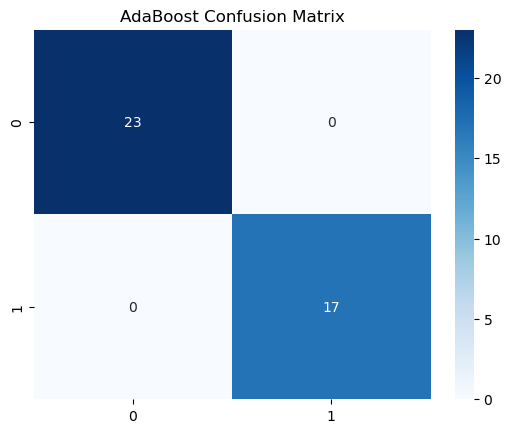

AdaBoost AUC: 1.0


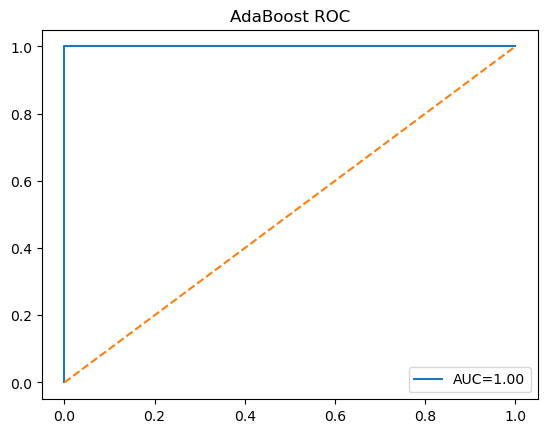

In [77]:
# 3.2 Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42).fit(X_train, y_train)
evaluate("Gradient Boosting", gb)
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42).fit(X_train, y_train)
evaluate("AdaBoost", ada)

=== Stacking ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



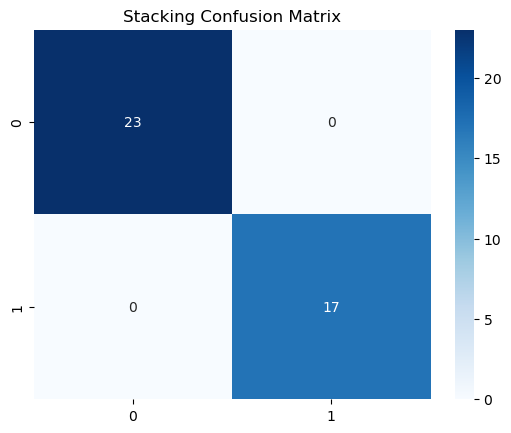

Stacking AUC: 1.0


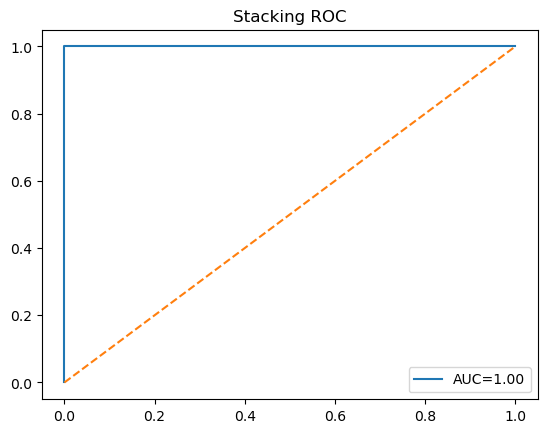

In [79]:
# 3.4 Stacking
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))
]
stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
).fit(X_train, y_train)
evaluate("Stacking", stack)


=== LogReg L1 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



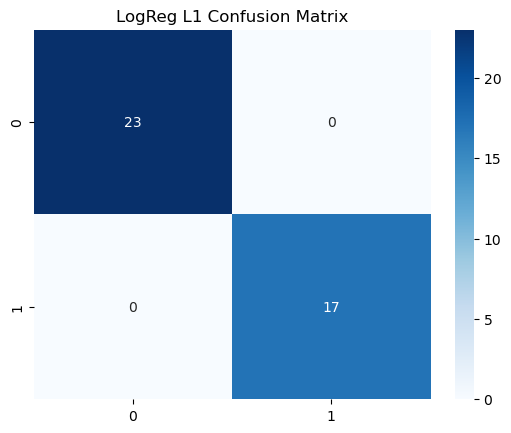

LogReg L1 AUC: 1.0


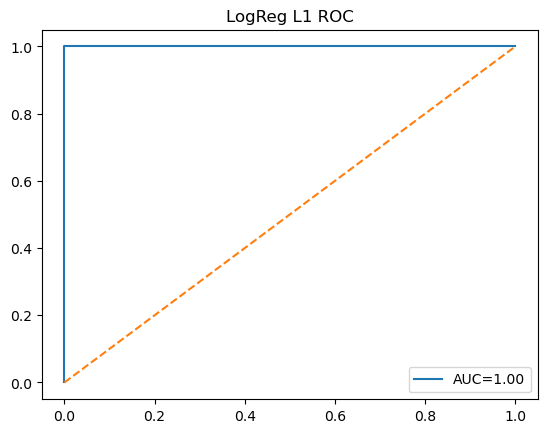

=== LogReg L2 ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



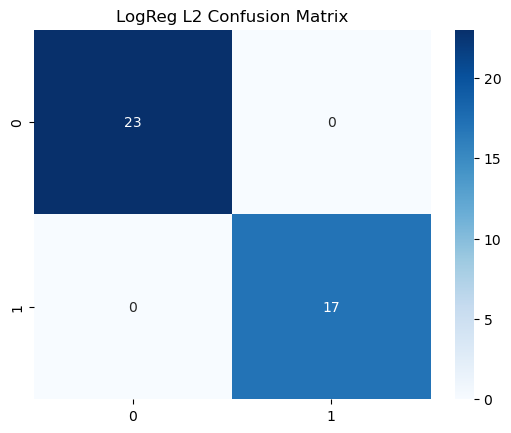

LogReg L2 AUC: 1.0


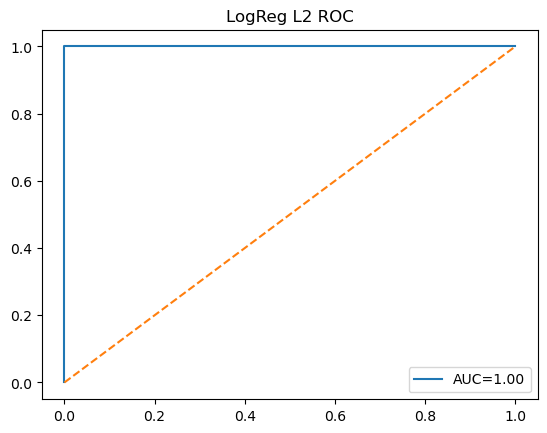

=== LogReg ElasticNet ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



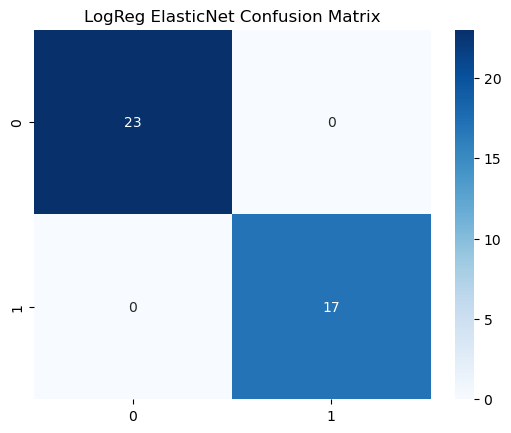

LogReg ElasticNet AUC: 1.0


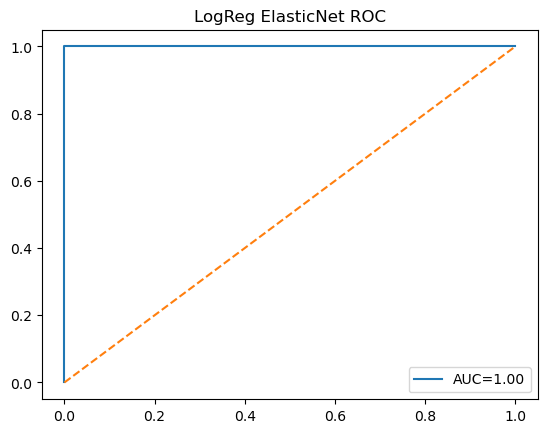

In [81]:
# 4.–– Regularization (Logistic w/ L1, L2, ElasticNet)
for penalty, params in [('L1',{'penalty':'l1','solver':'liblinear'}),
                        ('L2',{'penalty':'l2','solver':'liblinear'}),
                        ('ElasticNet',{'penalty':'elasticnet','l1_ratio':0.5,'solver':'saga'})]:
    model = LogisticRegression(C=1.0, **params, max_iter=500).fit(X_train, y_train)
    evaluate(f"LogReg {penalty}", model)

RF best params: {'max_depth': None, 'n_estimators': 50}
=== RF (GridSearch) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



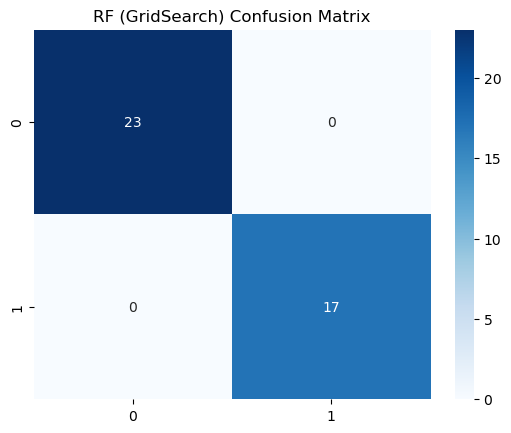

RF (GridSearch) AUC: 1.0


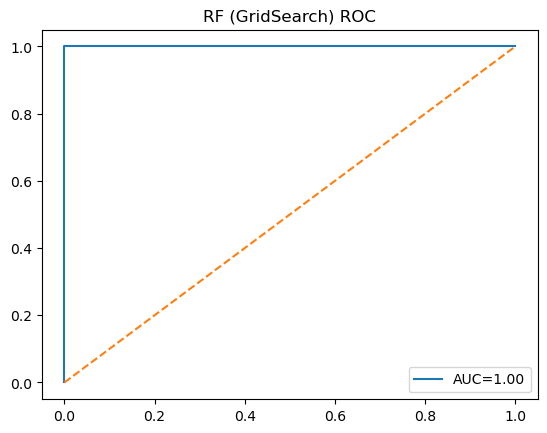

LR best params: {'C': 0.1, 'penalty': 'l1'}
=== LogReg (GridSearch) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



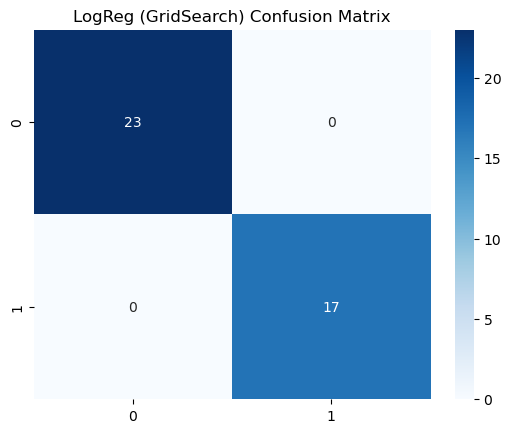

LogReg (GridSearch) AUC: 1.0


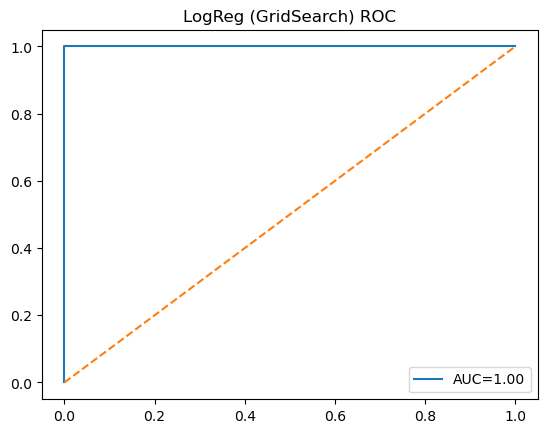

In [83]:
# 5.1 RF Grid Search
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_grid, cv=4, n_jobs=-1).fit(X_train, y_train)
print("RF best params:", gs_rf.best_params_)
evaluate("RF (GridSearch)", gs_rf.best_estimator_)

# 5.2 LR Grid Search (L1 vs L2)
lr_grid = {
    'penalty': ['l1','l2'],
    'C': [0.01, 0.1, 1, 10]
}
gs_lr = GridSearchCV(LogisticRegression(solver='liblinear', max_iter=500),
                     lr_grid, cv=4, n_jobs=-1).fit(X_train, y_train)
print("LR best params:", gs_lr.best_params_)
evaluate("LogReg (GridSearch)", gs_lr.best_estimator_)

In [ ]:
#What’s in here • Full preprocessing & scaling • PCA-based cluster plots + dendrogram • K-Means, Hierarchical, DBSCAN, GMM with silhouette scores • Supervised: RF, GB, Bagging, AdaBoost, Stacking • Regularized logistic (L1, L2, EN) • Classification reports, confusion matrices, ROC/AUC • Two grid-search examples (RF & LR)